In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
import cv2


## Dosyaların Okunması

In [ ]:
train_dir = "dataset/train/"
valid_dir = "dataset/valid/"
test_dir = "dataset/test/"

train_data = pd.read_csv(os.path.join(train_dir, "train.csv"))[["filename", "class"]]
valid_data = pd.read_csv(os.path.join(valid_dir, "valid.csv"))[["filename", "class"]]
test_data = pd.read_csv(os.path.join(test_dir, "test.csv"))[["filename", "class"]]


## Veri Yükleme ve Ön İşleme

In [ ]:
# Görselleri normalize ediyoruz (0-255 aralığından 0-1'e)
datagen = ImageDataGenerator(rescale=1./255)

# Eğitim verisi
train_generator = datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=train_dir,
    x_col="filename",
    y_col="class",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

# Doğrulama verisi
valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_data,
    directory=valid_dir,
    x_col="filename",
    y_col="class",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# Test verisi
test_generator = datagen.flow_from_dataframe(
    dataframe=test_data,
    directory=test_dir,
    x_col="filename",
    y_col="class",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 2576 validated image filenames belonging to 2 classes.
Found 709 validated image filenames belonging to 2 classes.
Found 377 validated image filenames belonging to 2 classes.


## Modelin Kurulması

In [ ]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(2, activation='sigmoid')  # İkili sınıflandırma yaptığımız için çıkış katmanında sigmoid aktivasyon fonksiyonu kullandık.
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Modelin Fit Edilmesi

In [5]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

c:\Users\Ahmet Safa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 43s 524ms/step - accuracy: 0.6163 - loss: 0.6759 - val_accuracy: 0.7898 - val_loss: 0.5392
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 344ms/step - accuracy: 0.7743 - loss: 0.5077 - val_accuracy: 0.7729 - val_loss: 0.5049
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 349ms/step - accuracy: 0.8394 - loss: 0.3840 - val_accuracy: 0.6629 - val_loss: 0.5819
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 347ms/step - accuracy: 0.8641 - loss: 0.3348 - val_accuracy: 0.7137 - val_loss: 0.5035
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 351ms/step - accuracy: 0.8823 - loss: 0.3020 - val_accuracy: 0.6911 - val_loss: 0.4836
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 349ms/step - accuracy: 0.8890 - loss: 0.2763 - val_accuracy: 0.7123 - val_loss: 0.4878
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 351ms/step - accuracy: 0.8952 - loss: 0.2552 - val_accuracy: 0.7250 - val_loss: 0.5034
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 346ms/step - accuracy: 0.8929 - loss: 0.2519 - val_accu

## Tahmin İşlemi

In [ ]:
# Test verisi üzerinde tahmin
y_pred_probs = model.predict(test_generator)  # Tahmin olasılıkları
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # En yüksek olasılığa sahip sınıfın indeksi

# Gerçek sınıf etiketleri
y_true_classes = test_generator.classes

c:\Users\Ahmet Safa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step


## Tahmin Verilerinin İncelenmesi

              precision    recall  f1-score   support

        mask       0.96      0.89      0.92       288
     no-mask       0.70      0.87      0.77        89

    accuracy                           0.88       377
   macro avg       0.83      0.88      0.85       377
weighted avg       0.89      0.88      0.88       377



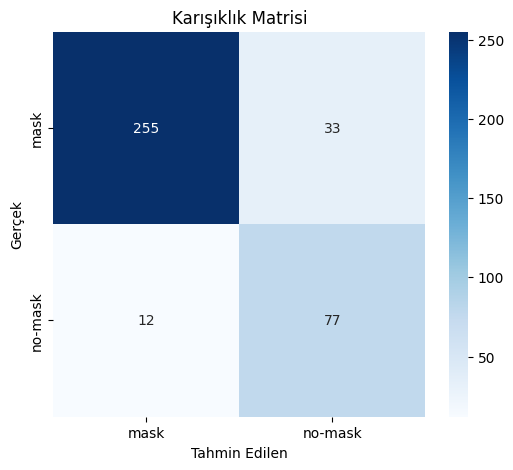

In [7]:
# Sınıf isimlerini alıyoruz
class_labels = list(test_generator.class_indices.keys())

# Sınıflandırma raporu
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

# Confusion matrix oluşturuyoruz
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Confusion matrix'i görselleştir
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("Karışıklık Matrisi")
plt.show()


## Kayıp ve Doğruluk Değerlerinin Görselleştirilmesi

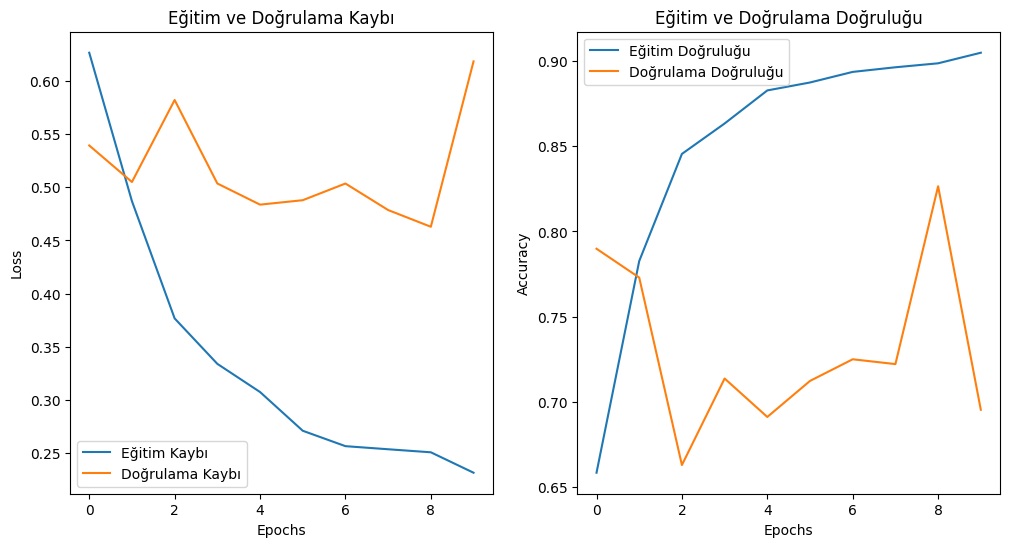

In [8]:
# Eğitim ve doğrulama kaybı ile doğruluğu görselleştir
plt.figure(figsize=(12, 6))

# Eğitim kaybı
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Eğitim doğruluğu
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## Örnek Çıktı

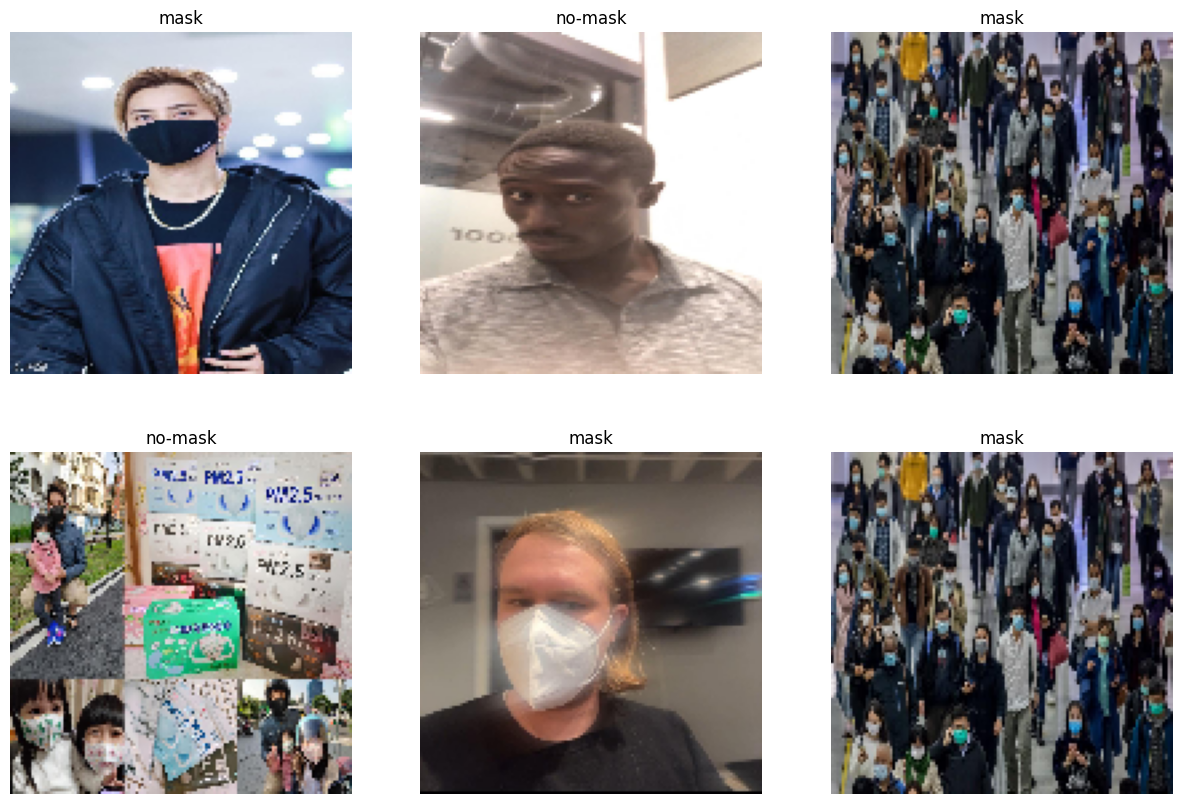

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(2):
    for j in range(3):
        index = i * 3 + j
        axes[i, j].imshow(test_generator[index][0][0])  # Görseli al
        label = class_labels[y_pred_classes[index]]  # Tahmin edilen etiket
        axes[i, j].set_title(label)
        axes[i, j].axis("off")


## Modelin Kaydedilmesi

In [10]:
# Modeli .h5 formatında kaydet
model.save('mask_model.h5')

## Canlı Kayıt Üzerinden Test

In [ ]:
# Modeli yüklüyoruz
model = tf.keras.models.load_model('mask_model.h5')

# OpenCV yüz algılayıcıyı kullanıyoruz
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# OpenCV ile video akışını başlat
cap = cv2.VideoCapture(0)

while True:
    # Kamera'dan bir kare alın
    ret, frame = cap.read()

    if not ret:
        break

    # Görüntüyü griye çeviriyoruz (Haar cascade yüz tespiti için)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Yüzleri tespit et
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Eğer yüz tespit edildiyse, her yüzü işleyin
    for (x, y, w, h) in faces:
        # Yüzü görüntüden kırp
        face = frame[y:y+h, x:x+w]
        
        # Yüzü model için uygun hale getiriyoruz
        image_resized = cv2.resize(face, (128, 128))  # Modelinizin input boyutuna göre ayar yapın
        image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
        image_normalized = image_rgb / 255.0  # Normalizasyon
        image_input = np.expand_dims(image_normalized, axis=0)

        # Tahmin
        predictions = model.predict(image_input)
        predicted_class = np.argmax(predictions, axis=1)

        # Tahmin edilen sınıfı al
        class_labels = ['maskesiz', 'maskeli']
        predicted_label = class_labels[predicted_class[0]]

        # Yüzün etrafına çerçeve çizip tahmin metnini gösteriyoruz
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, f'Tahmin: {predicted_label}', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Sonuçları video akışında gösteriyoruz
    cv2.imshow('Canlı Video', frame)

    # q tuşuna basarak programı sonlandırıyoruz
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Video akışını kapat
cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━